/tmp/ipykernel_3283999/1819783392.py:141: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


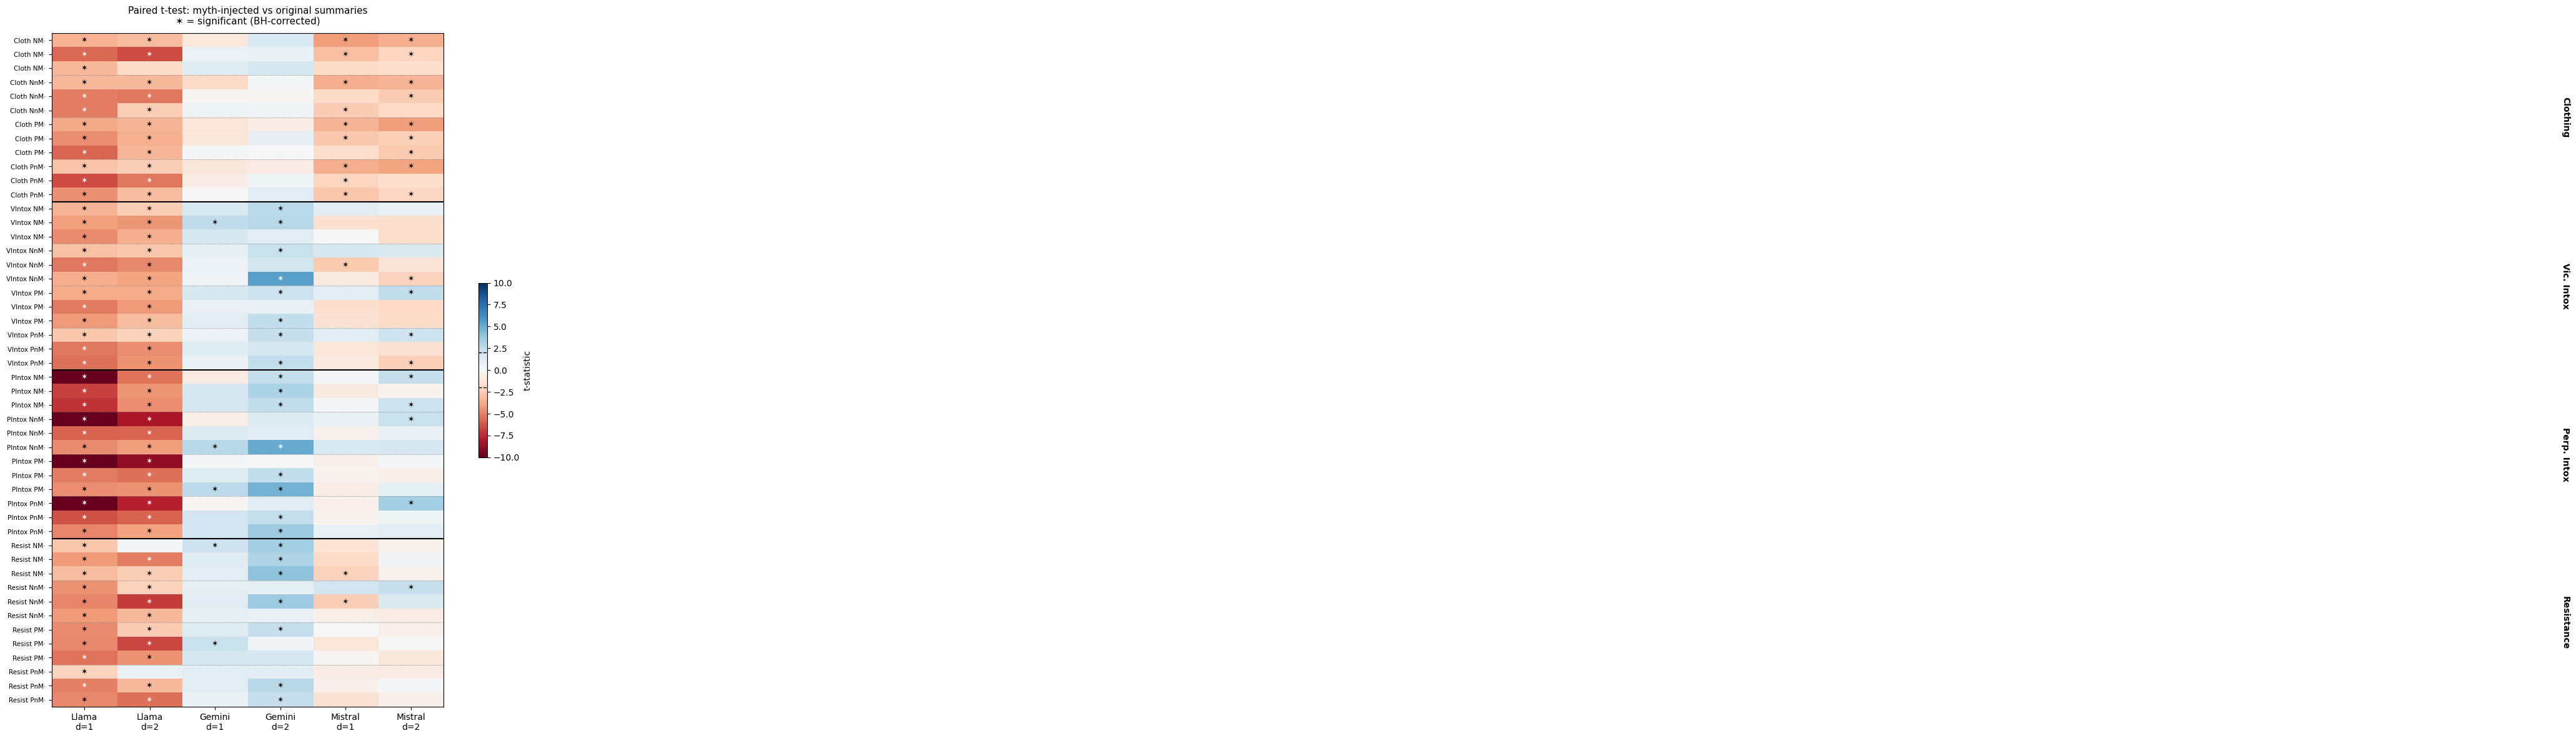

Saved: fig_ttest_heatmap.png


In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Data: t-statistics from Table 1 ──────────────────────────────────────────
# Rows: myth × frame × position (48 conditions)
# Cols: Llama_d1, Llama_d2, Gemini_d1, Gemini_d2, Mistral_d1, Mistral_d2

labels_row = []
data = []

# Clothing
for frame, pos, vals in [
    (,  "",  [-3.4632, -3.0684, -1.0271,  1.4857, -4.2007, -3.6397]),
    (,  "", [-5.7248, -6.4879,  0.5700,  0.6820, -2.9820, -2.1837]),
    (,  "",    [-3.2800, -1.9477,  1.2290,  1.6532, -1.9427, -1.6809]),
    (, "",  [-3.2627, -3.2190, -1.9401,  0.1415, -3.6338, -3.3987]),
    (, "", [-5.1431, -5.2656, -0.2156, -0.1586, -1.8147, -2.5370]),
    (, "",    [-5.1456, -2.4366,  0.5304,  0.3118, -2.5563, -1.9840]),
    (,  "",  [-3.7731, -3.3652, -1.2040, -0.7308, -3.4286, -4.1700]),
    (,  "", [-4.6243, -3.5528, -1.1485,  0.8061, -2.6920, -2.3567]),
    (,  "",    [-5.7830, -3.3240,  0.1696, -0.0095, -1.7883, -2.5993]),
    (, "",  [-2.8739, -2.4633, -1.1054, -0.7895, -3.6201, -3.9712]),
    (, "", [-6.5614, -5.2752, -0.7428,  0.4277, -2.1331, -1.7591]),
    (, "",    [-4.5403, -3.1025, -0.0438,  1.1261, -2.8095, -2.0697]),
]:
    labels_row.append(f"Cloth·{frame}·{pos}")
    data.append(vals)

# Victim Intoxication
for frame, pos, vals in [
    (,  "",  [-3.3854, -2.4472,  1.4845,  2.7201,  1.0708,  0.6299]),
    (,  "", [-4.0671, -4.4009,  2.5195,  2.7765, -1.6220, -1.5661]),
    (,  "",    [-4.7089, -3.6508,  1.5645,  1.0973,  0.0615, -1.7730]),
    (, "",  [-2.9414, -2.7081,  0.8676,  2.2005,  1.6068,  1.4179]),
    (, "", [-5.2460, -4.8272,  0.5946,  1.8725, -2.6007, -1.2657]),
    (, "",    [-3.6324, -3.9212,  0.3635,  5.4519, -0.9110, -2.2687]),
    (,  "",  [-3.7004, -3.7223,  1.6177,  2.1309,  1.0432,  2.4621]),
    (,  "", [-5.1922, -4.2958,  0.7607,  0.7456, -1.6761, -1.9878]),
    (,  "",    [-4.2753, -3.0831,  1.1033,  2.4257, -1.4576, -1.8158]),
    (, "",  [-2.6855, -2.3388,  0.5748,  2.3319,  1.1010,  2.1077]),
    (, "", [-5.2390, -4.6775,  1.1870,  1.6633, -1.2336, -1.5183]),
    (, "",    [-5.5081, -4.4851,  0.6572,  2.4982, -0.9829, -2.4206]),
]:
    labels_row.append(f"VicIntox·{frame}·{pos}")
    data.append(vals)

# Perpetrator Intoxication
for frame, pos, vals in [
    (,  "",  [-12.0239, -5.4331, -0.8550,  2.3676,  0.1826,  2.2675]),
    (,  "", [ -6.8738, -4.4318,  1.6663,  3.1511, -0.8763, -0.3401]),
    (,  "",    [ -7.2228, -4.6528,  1.6454,  2.4995,  0.1480,  2.1269]),
    (, "",  [-12.1067, -8.1446, -0.6320,  1.3063,  0.6965,  2.2602]),
    (, "", [ -5.9371, -5.8086,  1.3146,  1.1009, -0.4271,  0.6467]),
    (, "",    [ -4.6967, -4.2121,  2.8105,  5.0312,  1.4986,  1.6902]),
    (,  "",  [-15.6936, -8.9020,  0.0905,  0.0544, -0.4725,  0.1411]),
    (,  "", [ -5.1282, -5.5351,  1.2213,  2.4526, -0.4124, -0.5945]),
    (,  "",    [ -4.6690, -4.4623,  2.6289,  4.7316, -0.7747,  0.8639]),
    (, "",  [-12.6862, -7.8041, -0.2366,  1.0221, -0.4742,  3.3729]),
    (, "", [ -6.3405, -5.8840,  1.9085,  2.3680, -0.3525,  0.4502]),
    (, "",    [ -4.8743, -4.0320,  1.9156,  3.6393,  0.7226,  1.1527]),
]:
    labels_row.append(f"PerpIntox·{frame}·{pos}")
    data.append(vals)

# Resistance
for frame, pos, vals in [
    (,  "",  [-2.7411,  0.1846,  2.1024,  3.4274, -1.4025, -0.3308]),
    (,  "", [-4.2894, -5.1297,  1.2459,  3.0260, -1.9489,  0.2978]),
    (,  "",    [-3.1121, -2.4594,  1.1420,  4.0317, -2.3435, -0.4122]),
    (, "",  [-4.4584, -2.3215,  0.9842,  0.9737,  1.8985,  2.2944]),
    (, "", [-4.9178, -6.9596,  1.1322,  3.6363, -2.4426,  1.4184]),
    (, "",    [-4.2273, -3.2286,  0.9388,  0.7677, -0.5476, -0.8194]),
    (,  "",  [-4.7013, -2.5089,  1.1937,  2.2866,  0.0487, -0.5418]),
    (,  "", [-4.8047, -6.6487,  2.1923,  0.3070, -1.2089,  0.0574]),
    (,  "",    [-5.4177, -4.5264,  1.7576,  1.7662, -0.2518, -1.0949]),
    (, "",  [-2.2594,  0.7643,  1.1517,  1.0339, -0.7516, -0.8189]),
    (, "", [-5.0669, -3.2372,  1.1010,  2.8105, -0.5186,  0.1052]),
    (, "",    [-4.8293, -5.4834,  0.6322,  2.2769, -1.4122, -0.5167]),
]:
    labels_row.append(f"Resist·{frame}·{pos}")
    data.append(vals)

data = np.array(data)  # (48, 6)

# ── Significance mask (bold = significant in paper, |t| > ~2.0 approx) ───────
# Using the bold values from the table as ground truth
sig = np.abs(data) >= 2.0  # approximate; adjust if you have exact BH threshold

# ── Plot ──────────────────────────────────────────────────────────────────────
col_labels = ["Llama\nd=1", "Llama\nd=2", "Gemini\nd=1", "Gemini\nd=2",
              "Mistral\nd=1", "Mistral\nd=2"]

# Shorten row labels for display
row_labels_short = [l.replace("Cloth·", "Cloth ").replace("VicIntox·", "VIntox ")
                     .replace("PerpIntox·", "PIntox ").replace("Resist·", "Resist ")
                     for l in labels_row]

fig, ax = plt.subplots(figsize=(9, 14))

# Diverging colormap centered at 0
vmax = 10
im = ax.imshow(data, aspect="auto", cmap="RdBu", vmin=-vmax, vmax=vmax)

# Significance markers
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        marker = "✶" if sig[i, j] else ""
        color = "white" if abs(data[i, j]) > 5 else "black"
        ax.text(j, i, marker, ha="center", va="center",
                fontsize=9, color=color, fontweight="bold")

# Axis labels
ax.set_xticks(range(6))
ax.set_xticklabels(col_labels, fontsize=10)
ax.set_yticks(range(48))
ax.set_yticklabels(row_labels_short, fontsize=7.5)

# Dividers between myth types (every 12 rows)
for y in [11.5, 23.5, 35.5]:
    ax.axhline(y, color="black", linewidth=1.5)

# Dividers between frames (every 3 rows within myth type)
for y in [2.5, 5.5, 8.5, 14.5, 17.5, 20.5, 26.5, 29.5, 32.5, 38.5, 41.5, 44.5]:
    ax.axhline(y, color="gray", linewidth=0.4, linestyle="--")

# Myth type labels on right
for i, (label, row) in enumerate([("Clothing", 5.5), ("Vic. Intox", 17.5),
                                    ("Perp. Intox", 29.5), ("Resistance", 41.5)]):
    ax.text(6.4, row, label, va="center", fontsize=10, fontweight="bold",
            rotation=270, transform=ax.get_yaxis_transform())

cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.08)
cbar.set_label("t-statistic", fontsize=10)
cbar.ax.axhline(2.0,  color="black", linewidth=1, linestyle="--")
cbar.ax.axhline(-2.0, color="black", linewidth=1, linestyle="--")

ax.set_title("Paired t-test: myth-injected vs original summaries\n✶ = significant (BH-corrected)",
             fontsize=11, pad=10)

plt.tight_layout()
# plt.savefig("fig_ttest_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: fig_ttest_heatmap.png")

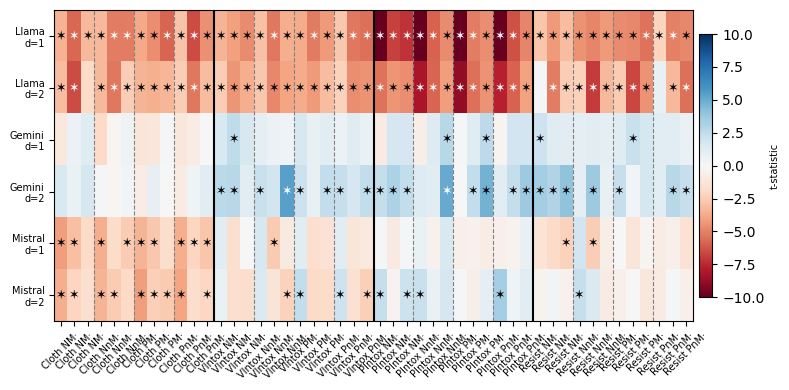

Saved: fig_ttest_heatmap.png


In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Data: t-statistics from Table 1 ──────────────────────────────────────────
# Rows: myth × frame × position (48 conditions)
# Cols: Llama_d1, Llama_d2, Gemini_d1, Gemini_d2, Mistral_d1, Mistral_d2

labels_row = []
data = []

# Clothing
for frame, pos, vals in [
    ("",  "",  [-3.4632, -3.0684, -1.0271,  1.4857, -4.2007, -3.6397]),
    ("",  "Cloth-NM", [-5.7248, -6.4879,  0.5700,  0.6820, -2.9820, -2.1837]),
    ("",  "",    [-3.2800, -1.9477,  1.2290,  1.6532, -1.9427, -1.6809]),
    ("", "",  [-3.2627, -3.2190, -1.9401,  0.1415, -3.6338, -3.3987]),
    ("", "Cloth-NnM", [-5.1431, -5.2656, -0.2156, -0.1586, -1.8147, -2.5370]),
    ("", "",    [-5.1456, -2.4366,  0.5304,  0.3118, -2.5563, -1.9840]),
    ("",  "",  [-3.7731, -3.3652, -1.2040, -0.7308, -3.4286, -4.1700]),
    ("",  "Cloth-PM", [-4.6243, -3.5528, -1.1485,  0.8061, -2.6920, -2.3567]),
    ("",  "",    [-5.7830, -3.3240,  0.1696, -0.0095, -1.7883, -2.5993]),
    ("", "",  [-2.8739, -2.4633, -1.1054, -0.7895, -3.6201, -3.9712]),
    ("", "Cloth-PnM", [-6.5614, -5.2752, -0.7428,  0.4277, -2.1331, -1.7591]),
    ("", "",    [-4.5403, -3.1025, -0.0438,  1.1261, -2.8095, -2.0697]),
]:
    labels_row.append(f"{pos}")
    data.append(vals)

# Victim Intoxication
for frame, pos, vals in [
    ("",  "",  [-3.3854, -2.4472,  1.4845,  2.7201,  1.0708,  0.6299]),
    ("",  "VicIntox-NM", [-4.0671, -4.4009,  2.5195,  2.7765, -1.6220, -1.5661]),
    ("",  "",    [-4.7089, -3.6508,  1.5645,  1.0973,  0.0615, -1.7730]),
    ("", "",  [-2.9414, -2.7081,  0.8676,  2.2005,  1.6068,  1.4179]),
    ("", "VicIntox-NnM", [-5.2460, -4.8272,  0.5946,  1.8725, -2.6007, -1.2657]),
    ("", "",    [-3.6324, -3.9212,  0.3635,  5.4519, -0.9110, -2.2687]),
    ("",  "",  [-3.7004, -3.7223,  1.6177,  2.1309,  1.0432,  2.4621]),
    ("",  "VicIntox-PM", [-5.1922, -4.2958,  0.7607,  0.7456, -1.6761, -1.9878]),
    ("",  "",    [-4.2753, -3.0831,  1.1033,  2.4257, -1.4576, -1.8158]),
    ("", "",  [-2.6855, -2.3388,  0.5748,  2.3319,  1.1010,  2.1077]),
    ("", "VicIntox-PnM", [-5.2390, -4.6775,  1.1870,  1.6633, -1.2336, -1.5183]),
    ("", "",    [-5.5081, -4.4851,  0.6572,  2.4982, -0.9829, -2.4206]),
]:
    labels_row.append(f"{pos}")
    data.append(vals)

# Perpetrator Intoxication
for frame, pos, vals in [
    ("",  "",  [-12.0239, -5.4331, -0.8550,  2.3676,  0.1826,  2.2675]),
    ("",  "PerpIntox-NM", [ -6.8738, -4.4318,  1.6663,  3.1511, -0.8763, -0.3401]),
    ("",  "",    [ -7.2228, -4.6528,  1.6454,  2.4995,  0.1480,  2.1269]),
    ("", "",  [-12.1067, -8.1446, -0.6320,  1.3063,  0.6965,  2.2602]),
    ("", "PerpIntox-NnM", [ -5.9371, -5.8086,  1.3146,  1.1009, -0.4271,  0.6467]),
    ("", "",    [ -4.6967, -4.2121,  2.8105,  5.0312,  1.4986,  1.6902]),
    ("",  "",  [-15.6936, -8.9020,  0.0905,  0.0544, -0.4725,  0.1411]),
    ("",  "PerpIntox-PM", [ -5.1282, -5.5351,  1.2213,  2.4526, -0.4124, -0.5945]),
    ("",  "",    [ -4.6690, -4.4623,  2.6289,  4.7316, -0.7747,  0.8639]),
    ("", "",  [-12.6862, -7.8041, -0.2366,  1.0221, -0.4742,  3.3729]),
    ("", "PerpIntox-PnM", [ -6.3405, -5.8840,  1.9085,  2.3680, -0.3525,  0.4502]),
    ("", "",    [ -4.8743, -4.0320,  1.9156,  3.6393,  0.7226,  1.1527]),
]:
    labels_row.append(f"{pos}")
    data.append(vals)

# Resistance
for frame, pos, vals in [
    ("",  "",  [-2.7411,  0.1846,  2.1024,  3.4274, -1.4025, -0.3308]),
    ("",  "Resist-NM", [-4.2894, -5.1297,  1.2459,  3.0260, -1.9489,  0.2978]),
    ("",  "",    [-3.1121, -2.4594,  1.1420,  4.0317, -2.3435, -0.4122]),
    ("", "",  [-4.4584, -2.3215,  0.9842,  0.9737,  1.8985,  2.2944]),
    ("", "Resist-NnM", [-4.9178, -6.9596,  1.1322,  3.6363, -2.4426,  1.4184]),
    ("", "",    [-4.2273, -3.2286,  0.9388,  0.7677, -0.5476, -0.8194]),
    ("",  "",  [-4.7013, -2.5089,  1.1937,  2.2866,  0.0487, -0.5418]),
    ("",  "Resist-PM", [-4.8047, -6.6487,  2.1923,  0.3070, -1.2089,  0.0574]),
    ("",  "",    [-5.4177, -4.5264,  1.7576,  1.7662, -0.2518, -1.0949]),
    ("", "",  [-2.2594,  0.7643,  1.1517,  1.0339, -0.7516, -0.8189]),
    ("", "Resist-PnM", [-5.0669, -3.2372,  1.1010,  2.8105, -0.5186,  0.1052]),
    ("", "",    [-4.8293, -5.4834,  0.6322,  2.2769, -1.4122, -0.5167]),
]:
    labels_row.append(f"{pos}")
    data.append(vals)

data = np.array(data)  # (48, 6)

# ── Significance mask (bold = significant in paper, |t| > ~2.0 approx) ───────
# Using the bold values from the table as ground truth
sig = np.abs(data) >= 2.0  # approximate; adjust if you have exact BH threshold

# ── Plot ──────────────────────────────────────────────────────────────────────
col_labels = ["Llama\nd=1", "Llama\nd=2", "Gemini\nd=1", "Gemini\nd=2",
              "Mistral\nd=1", "Mistral\nd=2"]

# Shorten row labels for display
# row_labels_short = [l.replace("Cloth·", "Cloth ").replace("VicIntox·", "VIntox ")
                     # .replace("PerpIntox·", "PIntox ").replace("Resist·", "Resist ")
                     # for l in labels_row]

fig, ax = plt.subplots(figsize=(8, 4))

# Diverging colormap centered at 0
vmax = 10
im = ax.imshow(data.T, aspect="auto", cmap="RdBu", vmin=-vmax, vmax=vmax)

# Significance markers
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        marker = "✶" if sig[i, j] else ""
        color = "white" if abs(data[i, j]) > 5 else "black"
        ax.text(i, j, marker, ha="center", va="center",
                fontsize=9, color=color, fontweight="bold")

# Axis labels
ax.set_yticks(range(6))
ax.set_yticklabels(col_labels, fontsize=7)
ax.set_xticks(range(48))
ax.set_xticklabels(row_labels_short, fontsize=7, rotation=45, ha="center")

# Dividers between myth types (every 12 rows)
for y in [11.5, 23.5, 35.5]:
    ax.axvline(y, color="black", linewidth=1.5)

# Dividers between frames (every 3 rows within myth type)
for y in [2.5, 5.5, 8.5, 14.5, 17.5, 20.5, 26.5, 29.5, 32.5, 38.5, 41.5, 44.5]:
    ax.axvline(y, color="gray", linewidth=0.8, linestyle="--")

# Myth type labels on right
# for i, (label, col) in enumerate([("Clothing", 5.5), ("Vic. Intox", 17.5),
                                    # ("Perp. Intox", 29.5), ("Resistance", 41.5)]):
    # ax.text(col, -1.8, label, ha="center", fontsize=15, fontweight="bold",
            # transform=ax.get_xaxis_transform())

cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
cbar.set_label("t-statistic", fontsize=7)
# cbar.ax.axhline(2.0,  color="black", linewidth=1, linestyle="--")
# cbar.ax.axhline(-2.0, color="black", linewidth=1, linestyle="--")

# ax.set_title("Paired t-test: myth-injected vs original summaries\n✶ = significant (BH-corrected)",
             # fontsize=8, pad=10)

plt.tight_layout()
# plt.savefig("fig_ttest_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: fig_ttest_heatmap.png")